# Mediation Probe

Set `TIER` and `TREATMENT_FACTOR` in the setup cell. The notebook renders the selected mediator tier and prompt-condition contrast from those settings when the setup cell runs.


In [1]:
import sys
sys.path.insert(0, '..')

from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from statsmodels.formula.api import ols

from shared.plot_utilities import setup_notebook_display, pvalue_to_stars
from shared.regression_utilities import (
    fit_regression,
)
from nuke.utils.load_replay_data import (
    CONDITION_FACTOR_META,
    CONDITION_FACTORS,
    REPLAY_TAG_JOIN_KEYS,
    add_canonical_replay_model,
    add_condition_factor_columns,
    filter_complete_replay_models,
    load_replay_data,
    safe_tier_name,
)

setup_notebook_display()

OUTCOME = 'replay_use_nuke_delta'
TREATMENT_FACTOR = 'real_world'
TIER = 'Simulation_Game'

TIERS = [
    'Explicit',
    'Nuclear',
    'Crisis_Urgency',
    'Simulation_Game',
]

GROUP_COLS = ['game_id', 'player_id']
DIRECT_COL = 'Direct (+mediator)'


def _factor_label(factor: str) -> str:
    return CONDITION_FACTOR_META[factor]['label']


def _condition_lookup_from_data(data: pd.DataFrame) -> dict[tuple[int, ...], str]:
    condition_cols = ['condition', *CONDITION_FACTORS]
    observed = data[condition_cols].drop_duplicates()
    return {
        tuple(int(row[factor]) for factor in CONDITION_FACTORS): str(row['condition'])
        for _, row in observed.iterrows()
    }


def _synthetic_condition_name(values: dict[str, int]) -> str:
    tokens = [
        CONDITION_FACTOR_META[factor]['token']
        for factor in CONDITION_FACTORS
        if int(values.get(factor, 0)) == 1
    ]
    return '-'.join(tokens) if tokens else 'original'


def _condition_name_from_values(values: dict[str, int]) -> str:
    key = tuple(int(values.get(factor, 0)) for factor in CONDITION_FACTORS)
    return CONDITION_BY_FACTOR_VALUES.get(key, _synthetic_condition_name(values))


def _condition_axis_label(condition: str) -> str:
    return str(condition).replace('-no-rationale', ' +\nno-rationale')


if TIER not in TIERS:
    raise ValueError(f'TIER must be one of {TIERS}; got {TIER!r}')

if TREATMENT_FACTOR not in CONDITION_FACTORS:
    raise ValueError(
        f'TREATMENT_FACTOR must be one of {CONDITION_FACTORS}; got {TREATMENT_FACTOR!r}'
    )

TIER_SOURCE_COL = f'tier_{TIER}'
MEDIATOR = f'rea_tier_{safe_tier_name(TIER)}'
MEDIATOR_LABEL = f'Reasoning: {TIER}'
MEDIATOR_SHORT_LABEL = TIER
TREATMENT_LABEL = _factor_label(TREATMENT_FACTOR)
TREATMENT_PROMPT_LABEL = f'{TREATMENT_LABEL} Prompting'
TREATMENT_LABEL_LOWER = TREATMENT_LABEL.lower()

# --- Load replay data ---
df = load_replay_data()
df = add_canonical_replay_model(df)
df, model_order = filter_complete_replay_models(df)
df = add_condition_factor_columns(df)

CONDITION_BY_FACTOR_VALUES = _condition_lookup_from_data(df)
baseline_values = {factor: 0 for factor in CONDITION_FACTORS}
treated_baseline_values = {**baseline_values, TREATMENT_FACTOR: 1}
BASELINE_CONDITION_LABEL = _condition_name_from_values(baseline_values)
BASELINE_TREATED_CONDITION_LABEL = _condition_name_from_values(treated_baseline_values)

# --- Merge reasoning tags ---
rea = pd.read_csv(Path('trails') / 'reasoning_trails_tagged.csv')

if TIER_SOURCE_COL not in rea.columns:
    available = [c.removeprefix('tier_') for c in rea.columns if c.startswith('tier_')]
    raise ValueError(f'{TIER_SOURCE_COL!r} not found. Available tiers: {available}')

rea_tags = rea[REPLAY_TAG_JOIN_KEYS + [TIER_SOURCE_COL]].rename(columns={TIER_SOURCE_COL: MEDIATOR})
df = df.merge(rea_tags, on=REPLAY_TAG_JOIN_KEYS, how='left')
df[MEDIATOR] = df[MEDIATOR].fillna(0).astype(int)

# Cluster column
df['_cluster'] = df['game_id'].astype(str) + '_' + df['player_id'].astype(str)

condition_factor_text = ', '.join(f'`{factor}`' for factor in CONDITION_FACTORS)

display(Markdown(f'''# Mediation Probe: {TREATMENT_PROMPT_LABEL}, {MEDIATOR_LABEL}, and Replay Nuke Delta

**Question:** To what extent does `{MEDIATOR}` account for the {TREATMENT_LABEL_LOWER} prompt condition's replay nuke-delta contrast?

**Research posture:** This is a factorial mediation probe, not a single universal mediation estimate.

The regression includes pairwise condition interactions among {condition_factor_text}. Therefore, the standalone `{TREATMENT_FACTOR}` coefficient is the **baseline {TREATMENT_LABEL_LOWER} contrast** (`{BASELINE_CONDITION_LABEL} -> {BASELINE_TREATED_CONDITION_LABEL}`), not the average effect across all conditions containing `{TREATMENT_FACTOR}`.

The diagnostic model estimates a `{TREATMENT_FACTOR} x {MEDIATOR}` interaction, so the mediator-outcome relationship can be conditional on treatment. The notebook therefore treats coefficient attenuation as an **indirect-effect proxy** and reports factorial contrasts explicitly.'''))

print(f'Selected tier: {TIER}')
print(f'Treatment factor: {TREATMENT_FACTOR}')
print(f'Mediator column: {MEDIATOR}')
print(f'Rows after complete-model filter: {len(df):,}')
print(f'Complete models: {len(model_order)}')
print(f'Clusters: {df["_cluster"].nunique()}')
print(f'{MEDIATOR_LABEL} prevalence: {df[MEDIATOR].mean():.1%}')


✓ Loaded 37,440 rows from 96 files
  Conditions   : original, no-rationale, real-world, real-world-no-rationale, ethical, ethical-real-world, ethical-no-rationale, real-world-no-rationale-ethical
  Replay models: DeepSeek-V3.2, DeepSeek-V4, GLM-4.7, GLM-5.1, Gemma-4, Kimi-K2.5, Kimi-K2.6, MiniMax-M2.7, Mistral-Small-4, Qwen-3.5, Qwen-3.6-27B, gpt-oss-120b

  Rows per condition × replay model:
  ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                       DeepSeek-V3.2      DeepSeek-V4          GLM-4.7          GLM-5.1          Gemma-4        Kimi-K2.5        Kimi-K2.6     MiniMax-M2.7  Mistral-Small-4         Qwen-3.5     Qwen-3.6-27B     gpt-oss-120b            Total
  ────────────────────────────────────────────────────────────────────────────────────────

# Mediation Probe: Real-world Prompting, Reasoning: Simulation_Game, and Replay Nuke Delta

**Question:** To what extent does `rea_tier_SimulationGame` account for the real-world prompt condition's replay nuke-delta contrast?

**Research posture:** This is a factorial mediation probe, not a single universal mediation estimate.

The regression includes pairwise condition interactions among `no_rationale`, `real_world`, `ethical`. Therefore, the standalone `real_world` coefficient is the **baseline real-world contrast** (`original -> real-world`), not the average effect across all conditions containing `real_world`.

The diagnostic model estimates a `real_world x rea_tier_SimulationGame` interaction, so the mediator-outcome relationship can be conditional on treatment. The notebook therefore treats coefficient attenuation as an **indirect-effect proxy** and reports factorial contrasts explicitly.

Selected tier: Simulation_Game
Treatment factor: real_world
Mediator column: rea_tier_SimulationGame
Rows after complete-model filter: 37,440
Complete models: 12
Clusters: 130
Reasoning: Simulation_Game prevalence: 7.2%


## Factorial Contrast Bootstrap Function

Cluster-bootstrap the difference-in-coefficients attenuation estimate for every configured treatment contrast:
- Resample `(game_id, player_id)` clusters with replacement
- Fit the base model and mediator-controlled model once per resample
- Compute each factorial treatment contrast from the relevant coefficient combination
- Report attenuation proxy, bootstrap SE, CI, and p-value for all contrasts


In [2]:
def _fit_ols_params(formula: str, data: pd.DataFrame) -> pd.Series:
    '''Fit OLS and return all coefficients.'''
    model = ols(formula, data=data)
    fit = model.fit()
    return fit.params


def _interaction_param(params: pd.Series, left: str, right: str) -> float:
    '''Return an interaction coefficient regardless of formula term order.'''
    return params.get(f'{left}:{right}', params.get(f'{right}:{left}', 0.0))


def _contrast_from_params(
    params: pd.Series,
    treatment: str,
    moderator_values: dict[str, int],
) -> float:
    '''Treatment contrast implied by the pairwise-interaction condition model.'''
    contrast = params.get(treatment, 0.0)
    for moderator, value in moderator_values.items():
        contrast += int(value) * _interaction_param(params, moderator, treatment)
    return contrast


def _condition_values_key(values: dict[str, int]) -> tuple[int, ...]:
    return tuple(int(values.get(factor, 0)) for factor in CONDITION_FACTORS)


def _moderator_value_specs(moderator_factors: list[str]) -> list[dict[str, int]]:
    specs = []
    for n_active in range(len(moderator_factors) + 1):
        for active in combinations(moderator_factors, n_active):
            active_set = set(active)
            specs.append({factor: int(factor in active_set) for factor in moderator_factors})
    return specs


def build_factorial_contrast_specs(
    data: pd.DataFrame,
    treatment: str,
    condition_factors: list[str],
) -> list[dict[str, object]]:
    '''Build observed untreated -> treated contrasts for a configurable treatment factor.'''
    if treatment not in condition_factors:
        raise ValueError(f'treatment must be one of {condition_factors}; got {treatment!r}')

    observed = _condition_lookup_from_data(data)
    moderator_factors = [factor for factor in condition_factors if factor != treatment]
    contrast_specs = []

    for moderator_values in _moderator_value_specs(moderator_factors):
        untreated_values = {factor: 0 for factor in condition_factors}
        untreated_values.update(moderator_values)
        treated_values = {**untreated_values, treatment: 1}

        untreated_key = _condition_values_key(untreated_values)
        treated_key = _condition_values_key(treated_values)
        missing = [
            _synthetic_condition_name(values)
            for key, values in [
                (untreated_key, untreated_values),
                (treated_key, treated_values),
            ]
            if key not in observed
        ]
        if missing:
            raise ValueError(
                'Cannot build factorial treatment contrasts because these condition '
                f'combinations are missing from the data: {missing}'
            )

        untreated_condition = observed[untreated_key]
        treated_condition = observed[treated_key]
        contrast_specs.append({
            'label': f'{untreated_condition} -> {treated_condition}',
            'moderator_values': moderator_values,
            'untreated_condition': untreated_condition,
            'treated_condition': treated_condition,
        })

    return contrast_specs


def bootstrap_factorial_contrasts(
    data: pd.DataFrame,
    outcome: str,
    treatment: str,
    mediator: str,
    contrast_specs: list[dict[str, object]],
    cluster_col: str = '_cluster',
    n_boot: int = 2000,
    seed: int = 42,
) -> tuple[pd.DataFrame, dict[str, np.ndarray]]:
    '''Bootstrap attenuation estimates for all configured factorial treatment contrasts.'''
    pairs = ' + '.join(f'{a} * {b}' for a, b in combinations(CONDITION_FACTORS, 2))
    base_formula = f'{outcome} ~ {pairs}'
    extended_formula = base_formula + f' + {mediator}'
    subset = data.dropna(subset=[outcome]).copy()

    base_params = _fit_ols_params(base_formula, subset)
    direct_params = _fit_ols_params(extended_formula, subset)

    point_rows = []
    for spec in contrast_specs:
        label = spec['label']
        moderator_values = spec['moderator_values']
        total = _contrast_from_params(base_params, treatment, moderator_values)
        direct = _contrast_from_params(direct_params, treatment, moderator_values)
        attenuation = total - direct
        point_rows.append({
            'Contrast': label,
            'Untreated condition': spec['untreated_condition'],
            'Treated condition': spec['treated_condition'],
            **moderator_values,
            'Total (base)': total,
            DIRECT_COL: direct,
            'Attenuation proxy': attenuation,
            '% Attenuated': attenuation / total if abs(total) > 1e-10 else np.nan,
        })

    rng = np.random.default_rng(seed)
    clusters = subset[cluster_col].unique()
    n_clusters = len(clusters)
    boot = {spec['label']: np.full(n_boot, np.nan) for spec in contrast_specs}

    for b in range(n_boot):
        sampled_clusters = rng.choice(clusters, size=n_clusters, replace=True)
        boot_data = pd.concat(
            [subset[subset[cluster_col] == cl] for cl in sampled_clusters],
            ignore_index=True,
        )
        try:
            base_b = _fit_ols_params(base_formula, boot_data)
            direct_b = _fit_ols_params(extended_formula, boot_data)
            for spec in contrast_specs:
                label = spec['label']
                moderator_values = spec['moderator_values']
                total_b = _contrast_from_params(base_b, treatment, moderator_values)
                direct_val_b = _contrast_from_params(direct_b, treatment, moderator_values)
                boot[label][b] = total_b - direct_val_b
        except Exception:
            continue

    rows = []
    for point in point_rows:
        label = point['Contrast']
        valid = boot[label][~np.isnan(boot[label])]
        ci_lower, ci_upper = np.percentile(valid, [2.5, 97.5])
        p_above = np.mean(valid > 0)
        p_below = np.mean(valid < 0)
        pvalue = 2 * min(p_above, p_below)
        rows.append({
            **point,
            'Bootstrap SE': float(np.std(valid)),
            'CI lower': ci_lower,
            'CI upper': ci_upper,
            'p': pvalue,
            'n_boot_valid': len(valid),
            'n_obs': len(subset),
        })

    return pd.DataFrame(rows).set_index('Contrast'), {k: v[~np.isnan(v)] for k, v in boot.items()}


def format_contrast_bootstrap_table(results: pd.DataFrame) -> pd.DataFrame:
    '''Format contrast bootstrap results for display.'''
    out = results.copy()
    out['Total (base)'] = out['Total (base)'].map('{:.3f}'.format)
    out[DIRECT_COL] = out[DIRECT_COL].map('{:.3f}'.format)
    out['Attenuation proxy'] = [
        f'{effect:.3f}{pvalue_to_stars(p)}'
        for effect, p in zip(out['Attenuation proxy'], out['p'])
    ]
    out['95% CI'] = [
        f'[{lo:.3f}, {hi:.3f}]'
        for lo, hi in zip(out['CI lower'], out['CI upper'])
    ]
    out['% Attenuated'] = out['% Attenuated'].map(
        lambda x: '--' if np.isnan(x) or abs(x) > 5 else f'{x:.1%}'
    )
    out['Bootstrap SE'] = out['Bootstrap SE'].map('{:.3f}'.format)
    out['p'] = out['p'].map('{:.4f}'.format)
    return out[[
        'Total (base)',
        DIRECT_COL,
        'Attenuation proxy',
        'Bootstrap SE',
        '95% CI',
        '% Attenuated',
        'p',
        'n_boot_valid',
        'n_obs',
    ]]


print('bootstrap_factorial_contrasts() defined.')


bootstrap_factorial_contrasts() defined.


In [3]:
display(Markdown(f'''## {MEDIATOR_LABEL} Prevalence and Factorial Setup

First check where `{MEDIATOR}` appears. Then define the factorial {TREATMENT_LABEL_LOWER} contrasts used throughout the notebook.'''))


## Reasoning: Simulation_Game Prevalence and Factorial Setup

First check where `rea_tier_SimulationGame` appears. Then define the factorial real-world contrasts used throughout the notebook.

In [4]:
pairs = ' + '.join(f'{a} * {b}' for a, b in combinations(CONDITION_FACTORS, 2))
base_formula = f'{OUTCOME} ~ {pairs}'
extended_formula_mediator = base_formula + f' + {MEDIATOR}'

subset = df.dropna(subset=[OUTCOME]).copy()

base_fit = fit_regression(base_formula, subset, group_cols=GROUP_COLS)
ext_mediator = fit_regression(extended_formula_mediator, subset, group_cols=GROUP_COLS)

# 1. Selected tag prevalence by condition
display(Markdown(f'### {MEDIATOR_LABEL} Prevalence by Condition'))
prev = df.groupby('condition', observed=True)[MEDIATOR].agg(['mean', 'sum', 'count'])
prev.columns = ['Prevalence', 'Count', 'Total']
prev['Prevalence'] = prev['Prevalence'].map('{:.1%}'.format)
display(prev)

# 2. Factorial treatment contrasts from the pairwise-interaction model
contrast_specs = build_factorial_contrast_specs(df, TREATMENT_FACTOR, CONDITION_FACTORS)

contrast_rows = []
for spec in contrast_specs:
    total = _contrast_from_params(base_fit.params, TREATMENT_FACTOR, spec['moderator_values'])
    direct = _contrast_from_params(ext_mediator.params, TREATMENT_FACTOR, spec['moderator_values'])
    attenuation = total - direct
    contrast_rows.append({
        'Contrast': spec['label'],
        'Untreated condition': spec['untreated_condition'],
        'Treated condition': spec['treated_condition'],
        **spec['moderator_values'],
        'Total (base)': total,
        DIRECT_COL: direct,
        'Attenuation proxy': attenuation,
        '% Attenuated': attenuation / total if abs(total) > 1e-10 else np.nan,
    })

contrast_df = pd.DataFrame(contrast_rows).set_index('Contrast')
print(f'Defined {len(contrast_df)} factorial {TREATMENT_LABEL_LOWER} contrasts for {OUTCOME}.')
print(f'R^2 comparison: Base = {base_fit.rsquared:.4f}, +{MEDIATOR_SHORT_LABEL} = {ext_mediator.rsquared:.4f}')


### Reasoning: Simulation_Game Prevalence by Condition

,Prevalence,Count,Total
condition,,,
ethical,12.6%,592,4680
ethical-no-rationale,15.9%,746,4680
ethical-real-world,9.5%,446,4680
no-rationale,2.4%,110,4680
original,1.8%,82,4680
real-world,2.5%,116,4680
real-world-no-rationale,2.3%,108,4680
real-world-no-rationale-ethical,10.7%,502,4680


Defined 4 factorial real-world contrasts for replay_use_nuke_delta.
R^2 comparison: Base = 0.1314, +Simulation_Game = 0.1481


## Factorial Contrast Bootstrap

Bootstrap the attenuation estimate for all configured factorial treatment contrasts, using cluster resampling at the `(game_id, player_id)` level.


In [5]:
import matplotlib.pyplot as plt

N_BOOT = 2000

print('Running factorial contrast bootstrap...')
contrast_bootstrap_df, contrast_boot_distributions = bootstrap_factorial_contrasts(
    df,
    OUTCOME,
    TREATMENT_FACTOR,
    MEDIATOR,
    contrast_specs,
    n_boot=N_BOOT,
)
print('Done.')


Running factorial contrast bootstrap...
Done.


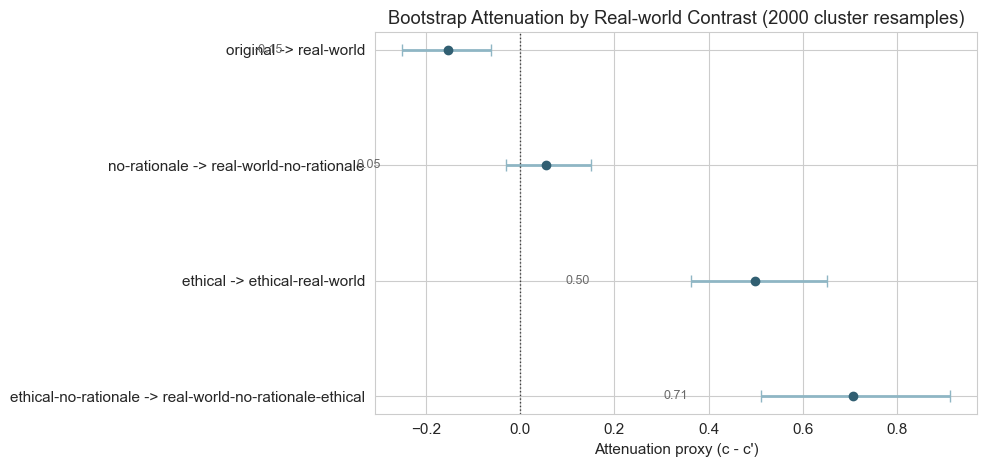

In [6]:
# --- Bootstrap contrast effect plot ---
plot_boot = contrast_bootstrap_df.reset_index()
y = np.arange(len(plot_boot))

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.errorbar(
    plot_boot['Attenuation proxy'],
    y,
    xerr=[
        plot_boot['Attenuation proxy'] - plot_boot['CI lower'],
        plot_boot['CI upper'] - plot_boot['Attenuation proxy'],
    ],
    fmt='o',
    color='#315f72',
    ecolor='#8fb6c4',
    elinewidth=2,
    capsize=4,
)
ax.axvline(0, color='black', linewidth=1, linestyle=':', alpha=0.7)
ax.set_yticks(y)
ax.set_yticklabels(plot_boot['Contrast'])
ax.invert_yaxis()
ax.set_xlabel("Attenuation proxy (c - c')")
ax.set_title(f'Bootstrap Attenuation by {TREATMENT_LABEL} Contrast ({N_BOOT} cluster resamples)')

for i, row in plot_boot.iterrows():
    ax.text(
        row['Attenuation proxy'] - 0.35,
        i,
        f'{row["Attenuation proxy"]:.2f}',
        ha='right',
        va='center',
        fontsize=9,
        color='dimgray',
    )

plt.tight_layout()
display(fig)
plt.close(fig)


In [7]:
display(Markdown(f'''## Conditional Mediator Diagnostic

The classic mediation path diagram assumes one mediator-outcome association. This diagnostic estimates whether `{MEDIATOR}` has the same relationship with replay nuke delta when `{TREATMENT_FACTOR} = 0` versus `{TREATMENT_FACTOR} = 1`.'''))


## Conditional Mediator Diagnostic

The classic mediation path diagram assumes one mediator-outcome association. This diagnostic estimates whether `rea_tier_SimulationGame` has the same relationship with replay nuke delta when `real_world = 0` versus `real_world = 1`.

In [8]:
interaction_formula = (
    f'{OUTCOME} ~ {pairs} + {MEDIATOR} + {TREATMENT_FACTOR}:{MEDIATOR}'
)
interaction_fit = fit_regression(interaction_formula, subset, group_cols=GROUP_COLS)

interaction_name = f'{TREATMENT_FACTOR}:{MEDIATOR}'
base_mediator_coef = interaction_fit.params.get(MEDIATOR, np.nan)
base_mediator_se = interaction_fit.bse.get(MEDIATOR, np.nan)
base_mediator_pval = interaction_fit.pvalues.get(MEDIATOR, np.nan)
ix_coef = interaction_fit.params.get(interaction_name, np.nan)
ix_se = interaction_fit.bse.get(interaction_name, np.nan)
ix_pval = interaction_fit.pvalues.get(interaction_name, np.nan)

treated_mediator_coef = base_mediator_coef + ix_coef
cov = interaction_fit.fit.cov_params()
try:
    treated_mediator_se = np.sqrt(
        cov.loc[MEDIATOR, MEDIATOR]
        + cov.loc[interaction_name, interaction_name]
        + 2 * cov.loc[MEDIATOR, interaction_name]
    )
except Exception:
    treated_mediator_se = np.nan

conditional_rows = pd.DataFrame([
    {
        'Quantity': f'{MEDIATOR_LABEL} effect when {TREATMENT_LABEL} = 0',
        'Estimate': base_mediator_coef,
        'Cluster SE': base_mediator_se,
        'p': base_mediator_pval,
    },
    {
        'Quantity': f'{MEDIATOR_LABEL} effect when {TREATMENT_LABEL} = 1',
        'Estimate': treated_mediator_coef,
        'Cluster SE': treated_mediator_se,
        'p': np.nan,
    },
    {
        'Quantity': f'Difference: {interaction_name}',
        'Estimate': ix_coef,
        'Cluster SE': ix_se,
        'p': ix_pval,
    },
])
conditional_mediator_df = conditional_rows.copy()
conditional_mediator_df['Estimate'] = conditional_mediator_df['Estimate'].map('{:.3f}'.format)
conditional_mediator_df['Cluster SE'] = conditional_mediator_df['Cluster SE'].map('{:.3f}'.format)
conditional_mediator_df['p'] = conditional_mediator_df['p'].map(
    lambda x: '--' if pd.isna(x) else f'{x:.4f}{pvalue_to_stars(x)}'
)

display(Markdown(f'### Conditional {MEDIATOR_LABEL} Association'))
display(conditional_mediator_df.set_index('Quantity'))
display(Markdown(
    f'The interaction estimate is `{ix_coef:.3f}` (p = {ix_pval:.4f}{pvalue_to_stars(ix_pval)}), '
    f'so the mediator-outcome association is not constant across `{TREATMENT_FACTOR} = 0` and `{TREATMENT_FACTOR} = 1` rows.'
))


### Conditional Reasoning: Simulation_Game Association

,Estimate,Cluster SE,p
Quantity,,,
Reasoning: Simulation_Game effect when Real-world = 0,-14.566,1.781,0.0000***
Reasoning: Simulation_Game effect when Real-world = 1,-14.312,1.922,--
Difference: real_world:rea_tier_SimulationGame,0.255,1.368,0.8523


The interaction estimate is `0.255` (p = 0.8523), so the mediator-outcome association is not constant across `real_world = 0` and `real_world = 1` rows.

In [9]:
display(Markdown(f'''## Visualizations

### Factorial Contrasts + Conditional {MEDIATOR_LABEL} Association
The left panel shows the configured {TREATMENT_LABEL_LOWER} contrasts implied by the condition-interaction model. The right panel replaces the classic path diagram with the conditional mediator-outcome association for `{MEDIATOR}`.

### Bootstrap Distributions
Histograms of bootstrap attenuation estimates for all configured factorial {TREATMENT_LABEL_LOWER} contrasts while controlling for `{MEDIATOR}`.'''))


## Visualizations

### Factorial Contrasts + Conditional Reasoning: Simulation_Game Association
The left panel shows the configured real-world contrasts implied by the condition-interaction model. The right panel replaces the classic path diagram with the conditional mediator-outcome association for `rea_tier_SimulationGame`.

### Bootstrap Distributions
Histograms of bootstrap attenuation estimates for all configured factorial real-world contrasts while controlling for `rea_tier_SimulationGame`.

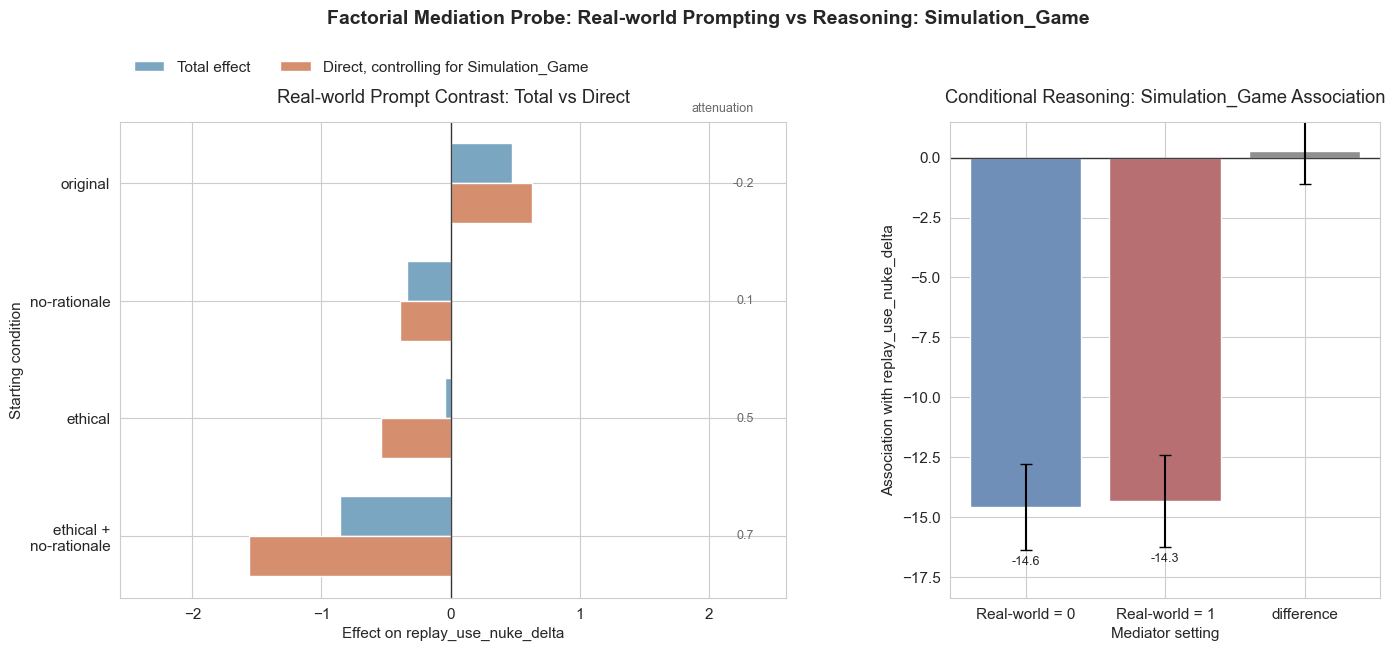

In [10]:
# --- Factorial contrasts and conditional mediator association ---

fig, (ax_left, ax_right) = plt.subplots(
    1,
    2,
    figsize=(14, 7),
    gridspec_kw={'width_ratios': [1.55, 1], 'wspace': 0.30},
)

plot_df = contrast_df.reset_index()
plot_df['Starting condition'] = plot_df['Untreated condition'].map(_condition_axis_label)
y = np.arange(len(plot_df))
bar_height = 0.34

ax_left.barh(
    y - bar_height / 2,
    plot_df['Total (base)'],
    height=bar_height,
    color='#7aa6c2',
    label='Total effect',
)
ax_left.barh(
    y + bar_height / 2,
    plot_df[DIRECT_COL],
    height=bar_height,
    color='#d58f6f',
    label=f'Direct, controlling for {MEDIATOR_SHORT_LABEL}',
)
ax_left.axvline(0, color='black', linewidth=1, alpha=0.75)
ax_left.set_yticks(y)
ax_left.set_yticklabels(plot_df['Starting condition'])
ax_left.invert_yaxis()
ax_left.set_xlabel(f'Effect on {OUTCOME}')
ax_left.set_ylabel('Starting condition')
ax_left.set_title(f'{TREATMENT_LABEL} Prompt Contrast: Total vs Direct', pad=14)
ax_left.legend(loc='lower left', bbox_to_anchor=(0.0, 1.07), ncol=2, frameon=False)

x_min = min(plot_df['Total (base)'].min(), plot_df[DIRECT_COL].min()) - 1.0
ax_left.set_xlim(x_min, 2.6)
ax_left.text(2.35, -0.58, 'attenuation', ha='right', va='bottom', fontsize=9, color='dimgray')
for i, row in plot_df.iterrows():
    attenuation = row['Attenuation proxy']
    ax_left.text(
        2.35,
        i,
        f'{attenuation:.1f}',
        va='center',
        ha='right',
        fontsize=9,
        color='dimgray',
    )

conditional_plot = pd.DataFrame([
    {
        'Quantity': f'{TREATMENT_LABEL} = 0',
        'Estimate': base_mediator_coef,
        'SE': base_mediator_se,
        'Color': '#6f8fb8',
    },
    {
        'Quantity': f'{TREATMENT_LABEL} = 1',
        'Estimate': treated_mediator_coef,
        'SE': treated_mediator_se,
        'Color': '#b86f72',
    },
    {
        'Quantity': 'difference',
        'Estimate': ix_coef,
        'SE': ix_se,
        'Color': '#8f8f8f',
    },
])

x_pos = np.arange(len(conditional_plot))
bars = ax_right.bar(
    x_pos,
    conditional_plot['Estimate'],
    yerr=conditional_plot['SE'],
    capsize=4,
    color=conditional_plot['Color'],
    edgecolor='white',
    linewidth=1,
)
ax_right.axhline(0, color='black', linewidth=1, alpha=0.75)
ax_right.set_xticks(x_pos)
ax_right.set_xticklabels(conditional_plot['Quantity'])
ax_right.set_xlabel('Mediator setting')
ax_right.set_ylabel(f'Association with {OUTCOME}')
ax_right.set_title(f'Conditional {MEDIATOR_LABEL} Association', pad=14)
ax_right.set_ylim(
    min((conditional_plot['Estimate'] - conditional_plot['SE']).min() - 2, -5),
    1.5,
)
ax_right.bar_label(bars, labels=[f'{v:.1f}' for v in conditional_plot['Estimate']], padding=4, fontsize=9)

fig.suptitle(
    f'Factorial Mediation Probe: {TREATMENT_PROMPT_LABEL} vs {MEDIATOR_LABEL}',
    fontsize=14,
    fontweight='bold',
    y=0.96,
)
fig.subplots_adjust(top=0.80, bottom=0.12, left=0.08, right=0.98)
display(fig)
plt.close(fig)


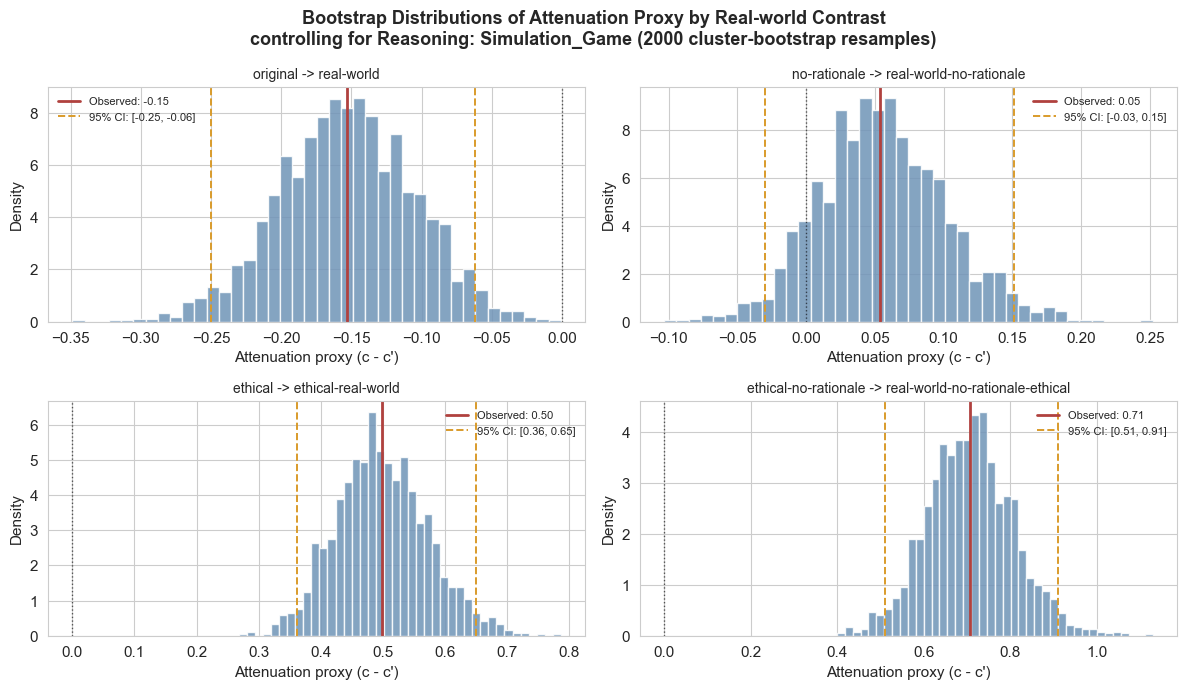

Bootstrap samples valid by contrast: {'original -> real-world': 2000, 'no-rationale -> real-world-no-rationale': 2000, 'ethical -> ethical-real-world': 2000, 'ethical-no-rationale -> real-world-no-rationale-ethical': 2000}


In [11]:
# --- Bootstrap distributions for all factorial contrasts ---
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=False, sharey=False)
axes = axes.ravel()

for ax, (label, dist) in zip(axes, contrast_boot_distributions.items()):
    row = contrast_bootstrap_df.loc[label]
    ax.hist(dist, bins=40, color='#6f94b7', edgecolor='white', alpha=0.85, density=True)
    ax.axvline(row['Attenuation proxy'], color='#b0413e', linewidth=2,
               label=f'Observed: {row["Attenuation proxy"]:.2f}')
    ax.axvline(row['CI lower'], color='#d99b2b', linewidth=1.4, linestyle='--')
    ax.axvline(row['CI upper'], color='#d99b2b', linewidth=1.4, linestyle='--',
               label=f'95% CI: [{row["CI lower"]:.2f}, {row["CI upper"]:.2f}]')
    ax.axvline(0, color='black', linewidth=1, linestyle=':', alpha=0.6)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("Attenuation proxy (c - c')")
    ax.set_ylabel('Density')
    ax.legend(fontsize=8, frameon=False)

fig.suptitle(
    f'Bootstrap Distributions of Attenuation Proxy by {TREATMENT_LABEL} Contrast\n'
    f'controlling for {MEDIATOR_LABEL} ({N_BOOT} cluster-bootstrap resamples)',
    fontsize=13,
    fontweight='bold',
)
plt.tight_layout()
display(fig)
plt.close(fig)

valid_counts = {label: len(dist) for label, dist in contrast_boot_distributions.items()}
print(f'Bootstrap samples valid by contrast: {valid_counts}')


In [12]:
display(Markdown(f'''## Per-Model Mediation Heatmap

Cells show the percent attenuation proxy for the selected mediator tier (`{MEDIATOR}`), fit separately for `[Overall]` and each complete replay model. Each annotation shows `% attenuated` and the total-to-direct comparison (`c -> c'`). These are descriptive attenuation diagnostics, not causal mediation estimates.'''))


## Per-Model Mediation Heatmap

Cells show the percent attenuation proxy for the selected mediator tier (`rea_tier_SimulationGame`), fit separately for `[Overall]` and each complete replay model. Each annotation shows `% attenuated` and the total-to-direct comparison (`c -> c'`). These are descriptive attenuation diagnostics, not causal mediation estimates.

In [13]:
PERCENT_ATTENUATION_TOTAL_EPS = 1e-10


def _safe_percent_attenuated(
    total: float,
    attenuation: float,
    eps: float = PERCENT_ATTENUATION_TOTAL_EPS,
) -> float:
    '''Return (c - c') / c, or NaN when the total effect is too close to zero.'''
    if pd.isna(total) or pd.isna(attenuation) or abs(total) <= eps:
        return np.nan
    return attenuation / total


def _mediation_heatmap_annotations(
    percent_attenuated: pd.DataFrame,
    total: pd.DataFrame,
    direct: pd.DataFrame,
    pvalues: pd.DataFrame,
    percent_fmt: str = '{:.0%}',
    value_fmt: str = '{:.2f}',
) -> np.ndarray:
    '''Build labels showing percent attenuated and the total-to-direct comparison.'''
    annot = np.empty(percent_attenuated.shape, dtype=object)
    for i in range(percent_attenuated.shape[0]):
        for j in range(percent_attenuated.shape[1]):
            pct = percent_attenuated.iloc[i, j]
            total_val = total.iloc[i, j]
            direct_val = direct.iloc[i, j]
            pval = pvalues.iloc[i, j]
            if pd.isna(total_val) and pd.isna(direct_val):
                annot[i, j] = ''
                continue

            pct_text = 'n/a' if pd.isna(pct) else percent_fmt.format(pct)
            stars = '' if pd.isna(pval) else pvalue_to_stars(pval)
            if pd.isna(total_val) or pd.isna(direct_val):
                compare_text = 'c -> c\' n/a'
            else:
                compare_text = f'{value_fmt.format(total_val)} -> {value_fmt.format(direct_val)}'
            annot[i, j] = f'{pct_text}{stars}\n{compare_text}'
    return annot


def _contrast_heatmap_label(label: str) -> str:
    '''Wrap contrast labels for heatmap axes.'''
    return str(label).replace(' -> ', '\n-> ')


def build_per_model_mediation_heatmap_data(
    data: pd.DataFrame,
    outcome: str,
    treatment: str,
    mediator: str,
    contrast_specs: list[dict[str, object]],
    model_order: list[str],
    model_col: str = 'replay_model_canonical',
    cluster_col: str = '_cluster',
    n_boot: int = 2000,
    seed: int = 420,
    include_overall: bool = True,
    overall_label: str = '[Overall]',
) -> tuple[pd.DataFrame, dict[str, object]]:
    '''Run the factorial mediation bootstrap overall and per replay model.'''
    contrast_labels = [str(spec['label']) for spec in contrast_specs]
    subset = data.dropna(subset=[outcome]).copy()

    fit_rows: list[tuple[str, pd.DataFrame]] = []
    if include_overall:
        fit_rows.append((overall_label, subset))
    for model_id in model_order:
        model_data = subset[subset[model_col] == model_id]
        fit_rows.append((model_id, model_data))

    empty_values = {label: np.nan for label in contrast_labels}
    total_rows: list[dict[str, float]] = []
    direct_rows: list[dict[str, float]] = []
    attenuation_rows: list[dict[str, float]] = []
    percent_rows: list[dict[str, float]] = []
    se_rows: list[dict[str, float]] = []
    pvalue_rows: list[dict[str, float]] = []
    valid_rows: list[dict[str, float]] = []
    nobs_rows: list[float] = []
    labels: list[str] = []
    raw_results: dict[str, pd.DataFrame] = {}
    errors: dict[str, str] = {}

    for row_ix, (label, fit_data) in enumerate(fit_rows):
        labels.append(label)
        if fit_data.empty:
            total_rows.append(empty_values.copy())
            direct_rows.append(empty_values.copy())
            attenuation_rows.append(empty_values.copy())
            percent_rows.append(empty_values.copy())
            se_rows.append(empty_values.copy())
            pvalue_rows.append(empty_values.copy())
            valid_rows.append(empty_values.copy())
            nobs_rows.append(0)
            errors[label] = 'No rows available for this model slice.'
            continue

        try:
            results, _ = bootstrap_factorial_contrasts(
                fit_data,
                outcome,
                treatment,
                mediator,
                contrast_specs,
                cluster_col=cluster_col,
                n_boot=n_boot,
                seed=seed + row_ix,
            )
            aligned = results.reindex(contrast_labels)
            raw_results[label] = aligned
            percent = pd.Series({
                contrast_label: _safe_percent_attenuated(
                    aligned.loc[contrast_label, 'Total (base)'],
                    aligned.loc[contrast_label, 'Attenuation proxy'],
                )
                for contrast_label in contrast_labels
            })
            total_rows.append(aligned['Total (base)'].to_dict())
            direct_rows.append(aligned[DIRECT_COL].to_dict())
            attenuation_rows.append(aligned['Attenuation proxy'].to_dict())
            percent_rows.append(percent.to_dict())
            se_rows.append(aligned['Bootstrap SE'].to_dict())
            pvalue_rows.append(aligned['p'].to_dict())
            valid_rows.append(aligned['n_boot_valid'].to_dict())
            nobs_rows.append(float(aligned['n_obs'].max()))
        except Exception as exc:
            total_rows.append(empty_values.copy())
            direct_rows.append(empty_values.copy())
            attenuation_rows.append(empty_values.copy())
            percent_rows.append(empty_values.copy())
            se_rows.append(empty_values.copy())
            pvalue_rows.append(empty_values.copy())
            valid_rows.append(empty_values.copy())
            nobs_rows.append(len(fit_data))
            errors[label] = str(exc)

    percent_attenuated = pd.DataFrame(percent_rows, index=labels, columns=contrast_labels)
    stats = {
        'total': pd.DataFrame(total_rows, index=labels, columns=contrast_labels),
        'direct': pd.DataFrame(direct_rows, index=labels, columns=contrast_labels),
        'attenuation': pd.DataFrame(attenuation_rows, index=labels, columns=contrast_labels),
        'bootstrap_se': pd.DataFrame(se_rows, index=labels, columns=contrast_labels),
        'p': pd.DataFrame(pvalue_rows, index=labels, columns=contrast_labels),
        'n_boot_valid': pd.DataFrame(valid_rows, index=labels, columns=contrast_labels),
        'n_obs': pd.Series(nobs_rows, index=labels, name='n_obs'),
        'raw_results': raw_results,
        'errors': errors,
    }
    return percent_attenuated, stats


def plot_per_model_mediation_heatmap(
    percent_attenuated: pd.DataFrame,
    stats: dict[str, object],
    title: str,
    n_boot: int,
    figsize: tuple[float, float] | None = None,
    cmap: str = 'RdBu_r',
    display_fig: bool = True,
) -> tuple[object, tuple[object, object]]:
    '''Render a per-model percent-attenuated heatmap with an n panel.'''
    import matplotlib.pyplot as plt
    import matplotlib.ticker as mtick
    import seaborn as sns

    finite = percent_attenuated.to_numpy(dtype=float)
    if np.isfinite(finite).any():
        vabs = max(float(np.nanmax(np.abs(finite))), 0.01)
    else:
        vabs = 0.01

    annot = _mediation_heatmap_annotations(
        percent_attenuated,
        stats['total'],
        stats['direct'],
        stats['p'],
    )
    nobs = stats['n_obs'].to_frame()
    n_annot = np.array([
        f'n={int(n)}' if not pd.isna(n) and int(n) > 0 else 'n/a'
        for n in stats['n_obs']
    ], dtype=object).reshape(-1, 1)

    if figsize is None:
        figsize = (max(10, percent_attenuated.shape[1] * 1.9 + 2.0), max(4, percent_attenuated.shape[0] * 0.50 + 1.8))

    fig, (ax_effect, ax_n) = plt.subplots(
        1,
        2,
        figsize=figsize,
        gridspec_kw={'width_ratios': [max(percent_attenuated.shape[1], 1), 0.8], 'wspace': 0.05},
        sharey=True,
    )

    heatmap = sns.heatmap(
        percent_attenuated,
        annot=annot,
        fmt='',
        cmap=cmap,
        center=0,
        vmin=-vabs,
        vmax=vabs,
        linewidths=0.5,
        linecolor='gray',
        cbar_kws={'label': "% attenuated proxy ((c - c') / c)", 'shrink': 0.8},
        ax=ax_effect,
    )
    cbar = heatmap.collections[0].colorbar
    if cbar is not None:
        cbar.ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
    ax_effect.set_ylabel('')
    ax_effect.set_xlabel('')
    ax_effect.set_title('% attenuated proxy', fontsize=11)
    ax_effect.set_xticklabels(
        [_contrast_heatmap_label(label) for label in percent_attenuated.columns],
        rotation=30,
        ha='right',
    )

    n_vmax = max(float(stats['n_obs'].max()) * 1.2, 1.0)
    sns.heatmap(
        nobs,
        annot=n_annot,
        fmt='',
        cmap='Greens',
        vmin=0,
        vmax=n_vmax,
        linewidths=0.5,
        linecolor='gray',
        cbar=False,
        ax=ax_n,
    )
    ax_n.set_ylabel('')
    ax_n.set_xlabel('')
    ax_n.set_title('Rows', fontsize=11)
    ax_n.set_xticklabels(['n'], rotation=0, ha='center')

    if percent_attenuated.index[0] == '[Overall]' and len(percent_attenuated) > 1:
        ax_effect.axhline(1, color='black', linewidth=1.2)
        ax_n.axhline(1, color='black', linewidth=1.2)

    fig.suptitle(title, fontsize=13, fontweight='bold', y=1.02)
    fig.text(
        0.02,
        -0.02,
        f"Cells: % attenuated proxy, with total-to-direct comparison (c -> c'). Stars test absolute attenuation c - c'. Near-zero totals show n/a. ({n_boot} cluster-bootstrap resamples per row)",
        fontsize=9,
        style='italic',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3),
    )
    plt.tight_layout()

    if display_fig:
        display(fig)
        plt.close(fig)

    return fig, (ax_effect, ax_n)


def format_per_model_absolute_attenuation_table(
    stats: dict[str, object],
    value_fmt: str = '{:.2f}',
    se_fmt: str = '{:.2f}',
) -> pd.DataFrame:
    '''Format c - c' with bootstrap SE so the absolute scale stays visible.'''
    attenuation = stats['attenuation']
    bootstrap_se = stats['bootstrap_se']
    pvalues = stats['p']
    formatted = pd.DataFrame(index=attenuation.index, columns=attenuation.columns, dtype=object)
    for i in range(attenuation.shape[0]):
        for j in range(attenuation.shape[1]):
            value = attenuation.iloc[i, j]
            se = bootstrap_se.iloc[i, j]
            pval = pvalues.iloc[i, j]
            if pd.isna(value):
                formatted.iloc[i, j] = ''
                continue
            se_text = 'NA' if pd.isna(se) else se_fmt.format(se)
            stars = '' if pd.isna(pval) else pvalue_to_stars(pval)
            formatted.iloc[i, j] = f'{value_fmt.format(value)} +/- {se_text}{stars}'
    return formatted


Running per-model factorial mediation bootstrap...
Done.


C:\Users\John Chen\AppData\Local\Temp\ipykernel_200668\2729544587.py:255: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


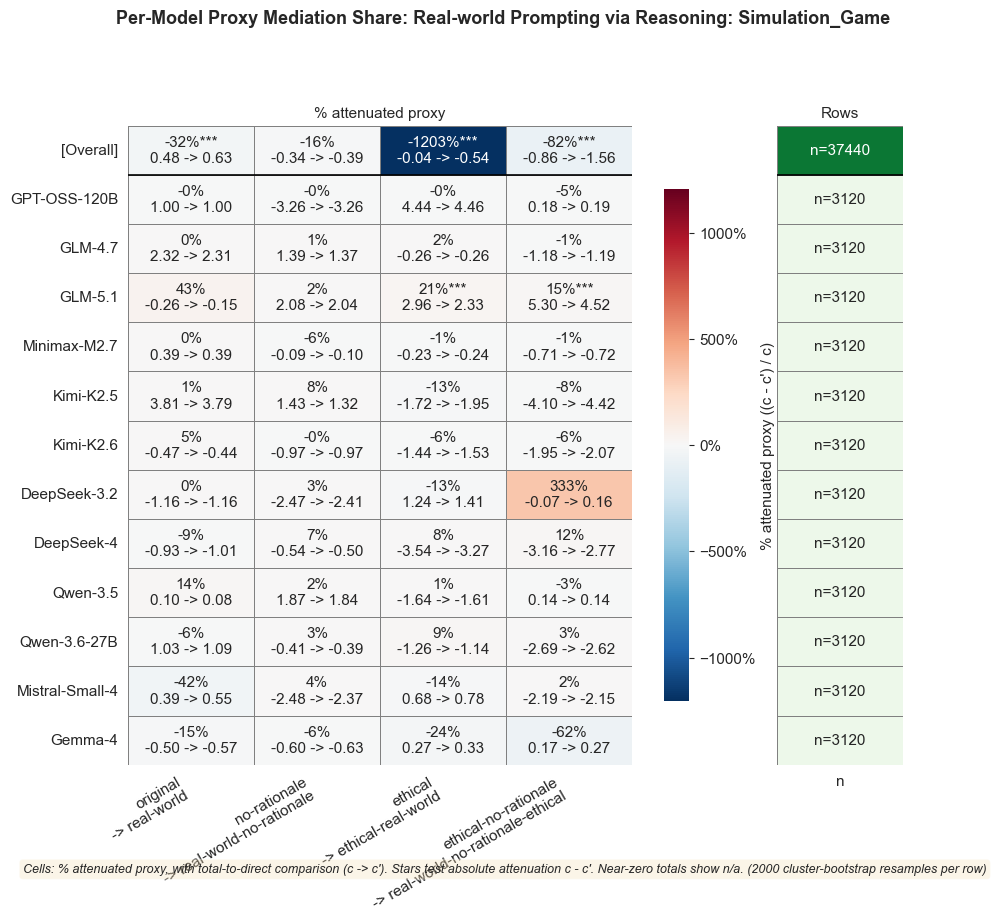

### Absolute attenuation proxy (`c - c'`)

,original -> real-world,no-rationale -> real-world-no-rationale,ethical -> ethical-real-world,ethical-no-rationale -> real-world-no-rationale-ethical
[Overall],-0.15 +/- 0.05***,0.05 +/- 0.05,0.50 +/- 0.07***,0.71 +/- 0.10***
GPT-OSS-120B,-0.00 +/- 0.03,0.00 +/- 0.03,-0.01 +/- 0.08,-0.01 +/- 0.07
GLM-4.7,0.01 +/- 0.06,0.02 +/- 0.12,-0.00 +/- 0.05,0.01 +/- 0.07
GLM-5.1,-0.11 +/- 0.14,0.04 +/- 0.12,0.64 +/- 0.23***,0.79 +/- 0.26***
Minimax-M2.7,0.00 +/- 0.01,0.01 +/- 0.01,0.00 +/- 0.01,0.01 +/- 0.01
Kimi-K2.5,0.02 +/- 0.06,0.11 +/- 0.09,0.23 +/- 0.16,0.32 +/- 0.22
Kimi-K2.6,-0.02 +/- 0.10,0.00 +/- 0.05,0.09 +/- 0.37,0.12 +/- 0.47
DeepSeek-3.2,-0.00 +/- 0.03,-0.07 +/- 0.09,-0.17 +/- 0.23,-0.23 +/- 0.31
DeepSeek-4,0.08 +/- 0.10,-0.04 +/- 0.07,-0.27 +/- 0.28,-0.39 +/- 0.38
Qwen-3.5,0.01 +/- 0.05,0.03 +/- 0.09,-0.02 +/- 0.07,-0.00 +/- 0.04


Heatmap rows: ['[Overall]', 'GPT-OSS-120B', 'GLM-4.7', 'GLM-5.1', 'Minimax-M2.7', 'Kimi-K2.5', 'Kimi-K2.6', 'DeepSeek-3.2', 'DeepSeek-4', 'Qwen-3.5', 'Qwen-3.6-27B', 'Mistral-Small-4', 'Gemma-4']
Heatmap contrasts: ['original -> real-world', 'no-rationale -> real-world-no-rationale', 'ethical -> ethical-real-world', 'ethical-no-rationale -> real-world-no-rationale-ethical']
Heatmap values: % Attenuated = (Total (base) - Direct (+mediator)) / Total (base)


In [14]:
PER_MODEL_N_BOOT = N_BOOT

print('Running per-model factorial mediation bootstrap...')
per_model_mediation_heatmap_df, per_model_mediation_heatmap_stats = build_per_model_mediation_heatmap_data(
    df,
    OUTCOME,
    TREATMENT_FACTOR,
    MEDIATOR,
    contrast_specs,
    model_order,
    n_boot=PER_MODEL_N_BOOT,
)
print('Done.')

plot_per_model_mediation_heatmap(
    per_model_mediation_heatmap_df,
    per_model_mediation_heatmap_stats,
    title=f'Per-Model Proxy Mediation Share: {TREATMENT_PROMPT_LABEL} via {MEDIATOR_LABEL}',
    n_boot=PER_MODEL_N_BOOT,
)

per_model_mediation_absolute_df = format_per_model_absolute_attenuation_table(
    per_model_mediation_heatmap_stats
)
display(Markdown("### Absolute attenuation proxy (`c - c'`)"))
display(per_model_mediation_absolute_df)

print(f'Heatmap rows: {list(per_model_mediation_heatmap_df.index)}')
print(f'Heatmap contrasts: {list(per_model_mediation_heatmap_df.columns)}')
print('Heatmap values: % Attenuated = (Total (base) - Direct (+mediator)) / Total (base)')
if per_model_mediation_heatmap_stats['errors']:
    print(f'Rows with unavailable estimates: {per_model_mediation_heatmap_stats["errors"]}')


In [15]:
display(Markdown(f'''## Interpretation

### What this supports
- {TREATMENT_LABEL} prompting changes `{MEDIATOR}` prevalence when the prevalence table shows a treatment difference.
- Controlling for `{MEDIATOR}` attenuates or amplifies each factorial {TREATMENT_LABEL_LOWER} contrast to the extent shown above.
- Use the total-to-direct comparison and `% Attenuated` heatmap to assess how much the selected mediator accounts for each prompt contrast.
- The remaining direct/other-pathway component can differ across the configured moderator settings.

### What this does not claim
- It does not estimate one universal {TREATMENT_LABEL_LOWER} mediation effect across all factorial conditions.
- It does not prove mediator causality without sequential ignorability assumptions.
- It does not imply `{MEDIATOR}` has the same relationship with the outcome in treated and untreated settings.'''))


## Interpretation

### What this supports
- Real-world prompting changes `rea_tier_SimulationGame` prevalence when the prevalence table shows a treatment difference.
- Controlling for `rea_tier_SimulationGame` attenuates or amplifies each factorial real-world contrast to the extent shown above.
- Use the total-to-direct comparison and `% Attenuated` heatmap to assess how much the selected mediator accounts for each prompt contrast.
- The remaining direct/other-pathway component can differ across the configured moderator settings.

### What this does not claim
- It does not estimate one universal real-world mediation effect across all factorial conditions.
- It does not prove mediator causality without sequential ignorability assumptions.
- It does not imply `rea_tier_SimulationGame` has the same relationship with the outcome in treated and untreated settings.

In [16]:
display(Markdown(f'''## Final Results Table

The final table reports the total effect, `{MEDIATOR}`-controlled direct effect, attenuation proxy, and cluster-bootstrap uncertainty for every configured factorial {TREATMENT_LABEL_LOWER} contrast.'''))


## Final Results Table

The final table reports the total effect, `rea_tier_SimulationGame`-controlled direct effect, attenuation proxy, and cluster-bootstrap uncertainty for every configured factorial real-world contrast.

In [17]:
display(Markdown(f'### Factorial {TREATMENT_LABEL} Contrast Bootstrap Results'))
display(format_contrast_bootstrap_table(contrast_bootstrap_df))


### Factorial Real-world Contrast Bootstrap Results

,Total (base),Direct (+mediator),Attenuation proxy,Bootstrap SE,95% CI,% Attenuated,p,n_boot_valid,n_obs
Contrast,,,,,,,,,
original -> real-world,0.477,0.630,-0.153***,0.048,"[-0.250, -0.062]",-32.1%,0.0000,2000,37440
no-rationale -> real-world-no-rationale,-0.338,-0.392,0.054,0.046,"[-0.030, 0.151]",-16.0%,0.2110,2000,37440
ethical -> ethical-real-world,-0.041,-0.540,0.499***,0.074,"[0.362, 0.650]",--,0.0000,2000,37440
ethical-no-rationale -> real-world-no-rationale-ethical,-0.856,-1.561,0.706***,0.101,"[0.511, 0.911]",-82.5%,0.0000,2000,37440
